# MENS ONLY - Shot Creation Logistic Regression Analysis

In [1]:
from __future__ import annotations
import warnings
from pathlib import Path
import polars as pl
import psutil
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings("ignore")

DATA_DIR = Path.cwd().parent/"Additional"
STATSBOMB_DIR = DATA_DIR/"Statsbomb"

_process = psutil.Process()

df = pl.read_parquet(DATA_DIR / "for_regression.parquet")
df = df.to_pandas()
df = df[df['OFF_MEN_WOMEN'] == 'M'].copy() #filter for mens only matches

In [2]:
# shape check
print(df.shape)

# null check
print(df.isnull().sum())

# binary variable creation; was a shot taken during the possession?
df['has_shot'] = (df['n_shots'] > 0).astype(int)
print(df['has_shot'].value_counts(normalize=True))

(538044, 39)
match_id                0
possession_type         0
period                  0
possession              0
OFF_TEAM_ID             0
OFF_MEN_WOMEN           0
OFF_BACKS               0
OFF_MIDFIELDERS         0
OFF_FORWARDS            0
OFF_GOALKEEPER          0
OFF_C0                  0
OFF_C1                  0
OFF_C2                  0
OFF_C3                  0
OFF_C4                  0
OFF_C5                  0
OFF_GK_C0               0
OFF_GK_C1               0
OFF_GK_C2               0
OFF_PLAYERS_ON_PITCH    0
DEF_TEAM_ID             0
DEF_MEN_WOMEN           0
DEF_BACKS               0
DEF_MIDFIELDERS         0
DEF_FORWARDS            0
DEF_GOALKEEPER          0
DEF_C0                  0
DEF_C1                  0
DEF_C2                  0
DEF_C3                  0
DEF_C4                  0
DEF_C5                  0
DEF_GK_C0               0
DEF_GK_C1               0
DEF_GK_C2               0
DEF_PLAYERS_ON_PITCH    0
total_xg                0
n_shots                 0

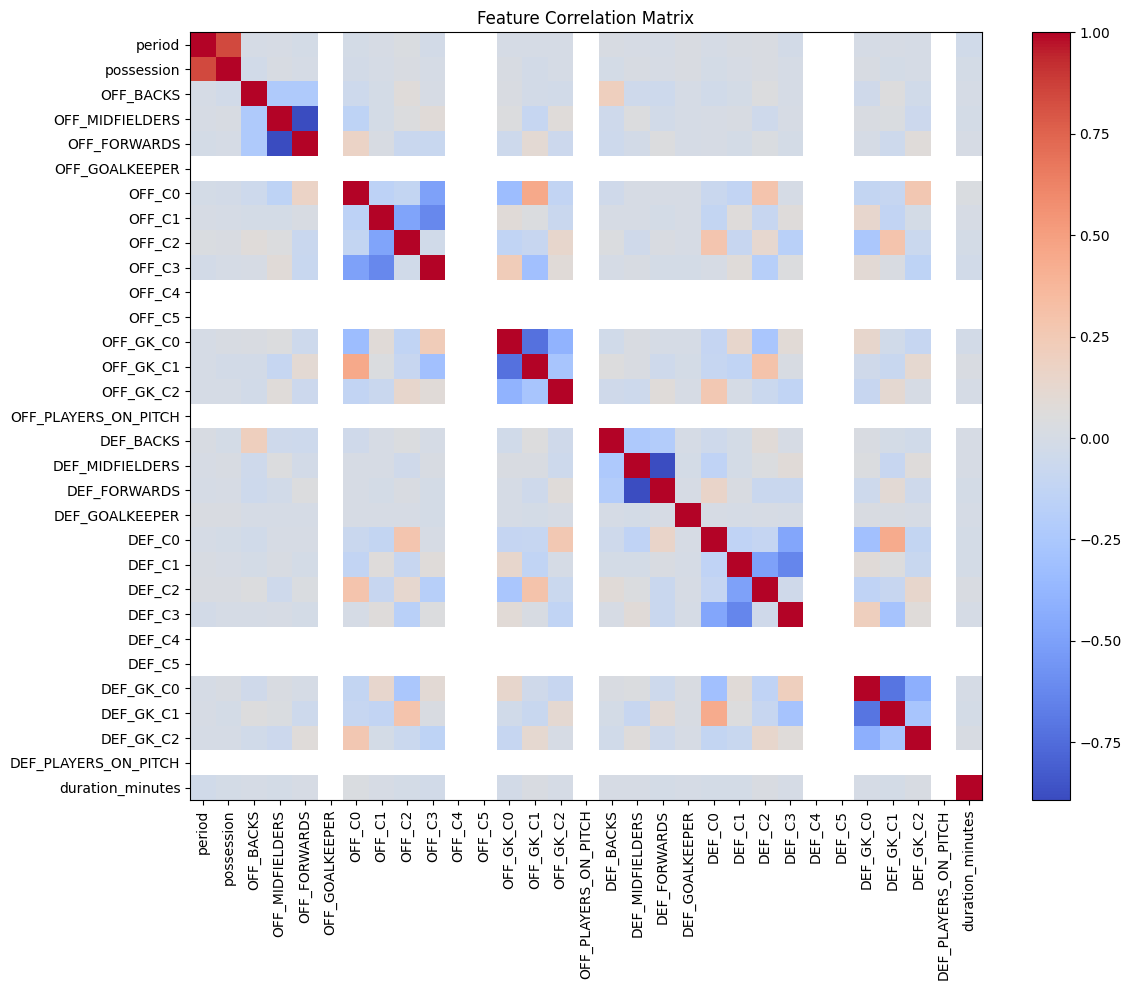

In [3]:
## correlation check

# columns to exclude from numeric features because they are not numbers, or they're response vars
exclude = ['possession_type', 'has_shot', 'total_xg', 'n_shots', 
           'match_id', 'OFF_TEAM_ID', 'DEF_TEAM_ID',
           'OFF_MEN_WOMEN', 'DEF_MEN_WOMEN']

numeric_features = [col for col in df.columns if col not in exclude]
corr_matrix = df[numeric_features].corr()
plt.figure(figsize=(12, 10))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(numeric_features)), numeric_features, rotation=90)
plt.yticks(range(len(numeric_features)), numeric_features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

* OFF_BACKS and OFF_MIDFIELDERS are strongly negatively correlated (same on defensive side), this is  because player position counts sum to a constant (11)
* Cluster columns C0–C5 show internal correlations, especially C3 with C1/C2, attributed to separate men's/women's clusters
* OFF_PLAYERS_ON_PITCH and DEF_PLAYERS_ON_PITCH are constants and  should be excluded from models
* Offensive and defensive features are largely independent of each other
* duration_minutes is uncorrelated with everything

In [4]:
# create DIFF features - men's only so C0-C3 only
for c in ['C0', 'C1', 'C2', 'C3']:
    df[f'DIFF_{c}'] = df[f'OFF_{c}'] - df[f'DEF_{c}']

for c in ['GK_C0', 'GK_C1', 'GK_C2']:
    df[f'DIFF_{c}'] = df[f'OFF_{c}'] - df[f'DEF_{c}']

# full VIF check
full_feature_cols = (
    ['duration_minutes',
     'OFF_BACKS', 'OFF_MIDFIELDERS', 'OFF_FORWARDS', 'OFF_GOALKEEPER',
     'DEF_BACKS', 'DEF_MIDFIELDERS', 'DEF_FORWARDS', 'DEF_GOALKEEPER',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2', 'DIFF_C3',
     'DIFF_GK_C0', 'DIFF_GK_C1', 'DIFF_GK_C2'] 
    + [col for col in df.columns if col.startswith('possession_type_')]
)

X_vif_full = df[full_feature_cols].astype(float)
vif_full = pd.DataFrame({
    'feature': full_feature_cols,
    'VIF': [variance_inflation_factor(X_vif_full.values, i)
            for i in range(X_vif_full.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_full.to_string())

             feature           VIF
1          OFF_BACKS           inf
2    OFF_MIDFIELDERS           inf
3       OFF_FORWARDS           inf
10           DIFF_C1  2.447906e+04
12           DIFF_C3  2.369337e+04
9            DIFF_C0  1.290453e+04
11           DIFF_C2  8.160984e+03
6    DEF_MIDFIELDERS  2.902990e+03
7       DEF_FORWARDS  2.853536e+03
5          DEF_BACKS  6.509932e+02
14        DIFF_GK_C1  1.254136e+01
13        DIFF_GK_C0  1.142895e+01
15        DIFF_GK_C2  6.530700e+00
8     DEF_GOALKEEPER  1.008696e+00
0   duration_minutes  1.001096e+00
4     OFF_GOALKEEPER  0.000000e+00


* OFF_BACKS, OFF_MIDFIELDERS, OFF_FORWARDS are perfectly collinear (inf VIF b/c they sum to a constant w/ OFF_GOALKEEPER).
* All position count columns have extreme VIF, probably should drop all position count columns
* duration_minutes has VIF around 1.0, meaning they're clean independent features

To sum up, position count columns add nothing beyond what the DIFF cluster features already capture. The variables duration_minutes, DIFF_C0, DIFF_C1, DIFF_C2 and possession type dummies should be used going forward. 

### Whittling it Down

In [5]:
df_model = pd.get_dummies(df, columns=['possession_type'], drop_first=True)
for c in ['C0', 'C1', 'C2', 'C3']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

for c in ['GK_C0', 'GK_C1', 'GK_C2']:
    df_model[f'DIFF_{c}'] = df_model[f'OFF_{c}'] - df_model[f'DEF_{c}']

feature_cols = (
    ['duration_minutes',
     'DIFF_C0', 'DIFF_C1', 'DIFF_C2',
     'DIFF_GK_C0', 'DIFF_GK_C1'] 
    + [col for col in df_model.columns if col.startswith('possession_type_')]
)

print(f"Number of features: {len(feature_cols)}")

X_vif = df_model[feature_cols].astype(float)
vif_data = pd.DataFrame({
    'feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_data.to_string())

Number of features: 13
                                      feature       VIF
5                                  DIFF_GK_C1  2.874821
4                                  DIFF_GK_C0  2.134015
3                                     DIFF_C2  1.649369
1                                     DIFF_C0  1.591480
2                                     DIFF_C1  1.350485
0                            duration_minutes  1.063218
11     possession_type_Middle Third - Patient  1.029643
7    possession_type_Defensive Third - Direct  1.018615
8   possession_type_Defensive Third - Patient  1.010762
10      possession_type_Middle Third - Direct  1.009059
6     possession_type_Attacking Third - Short  1.004197
12       possession_type_Middle Third - Short  1.003341
9     possession_type_Defensive Third - Short  1.000698


### Train/Test Split and Scaling

In [6]:
X = df_model[feature_cols].astype(float)
y = df_model['has_shot']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train shot rate: {y_train.mean():.4f}")
print(f"Test shot rate: {y_test.mean():.4f}")

Train size: (430435, 13)
Test size: (107609, 13)
Train shot rate: 0.1210
Test shot rate: 0.1210


### Model Fit and Initial Results

              precision    recall  f1-score   support

           0       0.92      0.52      0.66     94588
           1       0.16      0.66      0.26     13021

    accuracy                           0.54    107609
   macro avg       0.54      0.59      0.46    107609
weighted avg       0.83      0.54      0.61    107609

ROC-AUC: 0.6236


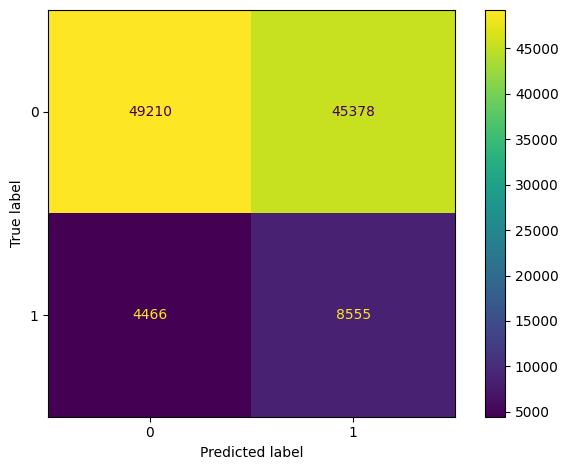

In [7]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.tight_layout()
plt.show()

Confusion matrix shows ~50,000 TNs, ~8,500 TPs, but 45,378 FPs. Balanced weighting is catching shots at the cost of raising a lot of false alarms.

In [8]:
# check shot rates by possession type to see if there's any signal at all
print(df.groupby('possession_type')['has_shot'].mean().sort_values(ascending=False))

# check if duration has any relationship with shots
print(f"\nMean duration - shot possessions: {df[df['has_shot']==1]['duration_minutes'].mean():.4f}")
print(f"Mean duration - no shot possessions: {df[df['has_shot']==0]['duration_minutes'].mean():.4f}")

possession_type
Defensive Third - Patient    0.223437
Attacking Third - Patient    0.208337
Middle Third - Direct        0.200161
Middle Third - Patient       0.162584
Attacking Third - Short      0.137850
Defensive Third - Short      0.135385
Defensive Third - Direct     0.100959
Middle Third - Short         0.063059
Name: has_shot, dtype: float64

Mean duration - shot possessions: 0.3865
Mean duration - no shot possessions: 0.3152


Shot rate by possession type shows some variation: 'Defensive Third - Patient' top @ 22.3%, 'Middle Third - Short' lowest @ 6.3%. Shot possessions have slightly longer mean duration (0.39 min) vs. non-shot possessions (0.32 min).

In [9]:
# find optimal threshold using precision-recall curve
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * precision_vals * recall_vals / (precision_vals + recall_vals + 1e-8)
optimal_threshold = thresholds[f1_scores.argmax()]
print(f"Optimal threshold: {optimal_threshold:.4f}")

Optimal threshold: 0.5066


### Inference

In [10]:
X_train_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.358615
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               has_shot   No. Observations:               430435
Model:                          Logit   Df Residuals:                   430421
Method:                           MLE   Df Model:                           13
Date:                Mon, 13 Apr 2026   Pseudo R-squ.:                 0.02791
Time:                        22:14:38   Log-Likelihood:            -1.5436e+05
converged:                       True   LL-Null:                   -1.5879e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.0603      0.005   -410.541      0.000      -2.070      -2.050
x1             0.0013      0.

In [11]:
feature_names = ['const'] + feature_cols
summary_df = pd.DataFrame({
    'variable': feature_names,
    'coefficient': result.params.values,
    'odds_ratio': np.exp(result.params.values),
    'p_value': result.pvalues.values
}).query("variable != 'const'").sort_values('odds_ratio', ascending=False)
print(summary_df.to_string())

                                     variable  coefficient  odds_ratio        p_value
2                                     DIFF_C0     0.028415    1.028822   1.593537e-06
6                                  DIFF_GK_C1     0.011553    1.011620   1.481437e-01
3                                     DIFF_C1     0.003390    1.003396   5.365578e-01
9   possession_type_Defensive Third - Patient     0.002507    1.002510   5.185354e-01
1                            duration_minutes     0.001311    1.001312   7.486741e-01
11      possession_type_Middle Third - Direct    -0.002245    0.997758   7.229882e-01
5                                  DIFF_GK_C0    -0.017137    0.983009   1.291875e-02
12     possession_type_Middle Third - Patient    -0.060273    0.941508   1.028434e-29
4                                     DIFF_C2    -0.105145    0.900194   1.691757e-68
10    possession_type_Defensive Third - Short    -0.163890    0.848836  8.856998e-104
7     possession_type_Attacking Third - Short    -0.18

### Cross-Validation

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
print(f"\nCV ROC-AUC scores: {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")


CV ROC-AUC scores: [0.62369235 0.62614526 0.62985468 0.62311698 0.6252844 ]
Mean: 0.6256 (+/- 0.0024)


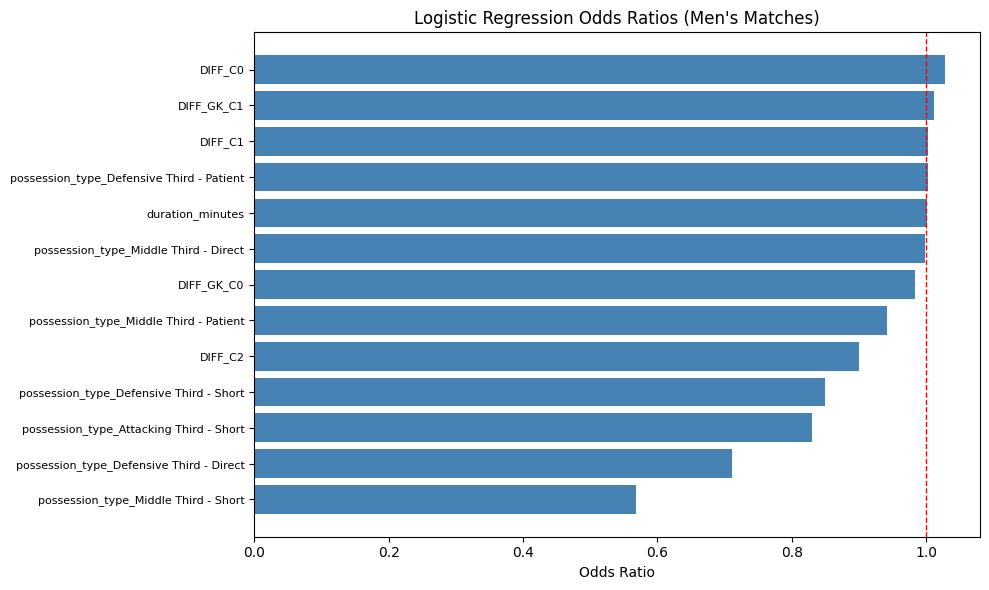

In [13]:
full_plot = summary_df.sort_values('odds_ratio')

plt.figure(figsize=(10, 6))
plt.barh(full_plot['variable'], full_plot['odds_ratio'], color='steelblue')
plt.axvline(x=1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Odds Ratio')
plt.title('Logistic Regression Odds Ratios (Men\'s Matches)')
plt.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.show()

**Summary: We created a logistic regression model predicting whether a possession produces a shot, fitted on men's matches only (n = 538,044 possessions, 12.1% shot rate). Feature set includes possession type dummies, duration, DIFF_C0–C2 (C3 as implicit reference), and GK cluster differentials DIFF_GK_C0 and DIFF_GK_C1 (GK_C2 as implicit reference). IS_MENS and women's cluster features removed as not applicable.**

Highlights:

* All possession types reduce shot probability relative to the "Attacking Third - Patient" baseline. The reference category is the most "dangerous" possession type.
* "Middle Third - Short" has the strongest negative effect (OR 0.568). These are short, leads-nowehere midfield possessions which are the least likely to produce shots
* "Defensive Third - Direct" is also very negative (OR 0.712). These may be quick clearances from deep, which would rarely result in shots
* DIFF_C2 is the strongest negative cluster effect (OR 0.900). This means that having more C2-type players on offense relative to defense would *reduce* shot probability.
* DIFF_GK_C0 is negative and significant (OR 0.983, p=0.013). Having more GK_C0-type goalkeepers on offense relative to defense slightly reduces shot probability
* DIFF_GK_C1 is not statistically significant (p=0.148)
* Several variables are also not significant: duration_minutes (p=0.749), DIFF_C1 (p=0.537), Defensive Third - Patient (p=0.519), Middle Third - Direct (p=0.723), DIFF_GK_C1 (p=0.148), Middle Third - Direct (p=0.723)

Model performance:

* ROC-AUC of 0.624 on test set, CV mean of 0.626 (std 0.002). Stable and consistent
* Pretty much identical to the pooled model (0.628), meaning that C4/C5 and IS_MENS were not adding a whole lot of signal for men's matches
* Pseudo R^2 of 0.028, pretty consistent with the pooled model
* class_weight='balanced' used to handle 88/12 class imbalance

Notes:

* Reference category is "Attacking Third - Patient" 
* Men's matches only — 538,044 of 642,410 total possessions
* statsmodels inference uses unweighted logistic regression for coefficient interpretation; the AUC difference between weighted and unweighted models is negligible